# Decision Tree

### 수업자료 06_machin_learning\09_결정트리와 랜덤포레스트.ipynb에 근거한 Decision Tree와 Random Forest 모델링 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [3]:
df = pd.read_csv("../data/synthetic_customer_churn_100k.csv", skipinitialspace=True)
df.shape

(100000, 9)

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


In [6]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [13]:
df["testfier"] = df["Tenure"]*df["MonthlyCharges"]-df["TotalCharges"]
df = df.sort_values('testfier', ascending=False)
df
(df["Tenure"] != 0).sum()

np.int64(100000)

In [17]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn,testfier
45954,45955,51,Male,50,77.32,Two year,Mailed check,3648.06,No,217.94
45646,45647,64,Male,61,84.37,Month-to-month,Credit card,4944.05,Yes,202.52
14693,14694,36,Female,2,72.63,Month-to-month,Credit card,-49.45,Yes,194.71
30071,30072,59,Female,45,90.66,Two year,Bank transfer,3886.36,No,193.34
65366,65367,75,Male,19,99.10,One year,Mailed check,1689.99,No,192.91
...,...,...,...,...,...,...,...,...,...,...
41643,41644,77,Male,6,132.52,One year,Bank transfer,1004.10,Yes,-208.98
8934,8935,78,Male,9,78.37,Month-to-month,Electronic check,917.70,No,-212.37
16445,16446,61,Female,58,109.83,Month-to-month,Mailed check,6587.27,Yes,-217.13
43587,43588,32,Male,3,44.03,Month-to-month,Mailed check,354.74,Yes,-222.65


In [27]:
df["testfier"].describe()

count    100000.000000
mean          0.142277
std          50.042269
min        -224.970000
25%         -33.460000
50%          -0.120000
75%          34.030000
max         217.940000
Name: testfier, dtype: float64

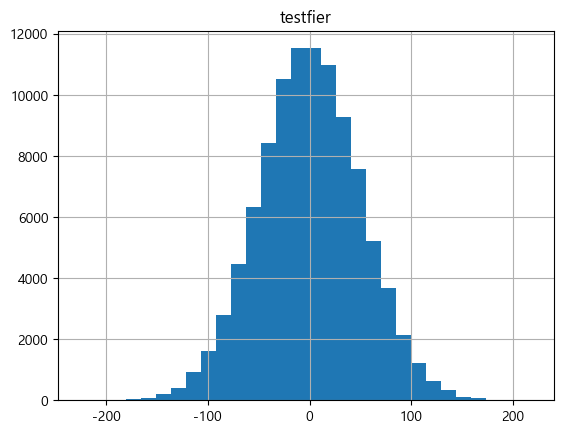

In [26]:
df["testfier"].hist(bins=30)
plt.title("testfier")
plt.show()

### EDA 분석 권고에 따라 TotalCharges 음수값을 0으로 대체
### categorical_columns은 label encoding을 하고
### numeric_columns은 scalinf 하지 않음

In [42]:
# 음수 개수 확인
neg_count = (df['TotalCharges'] < 0).sum()
print(f"음수 개수: {neg_count}개")

# 0으로 교체
df['TotalCharges'] = df['TotalCharges'].apply(lambda x: 0 if x < 0 else x)
neg_count = (df['TotalCharges'] < 0).sum()
print(f"음수 개수: {neg_count}개")

음수 개수: 265개
음수 개수: 0개


In [43]:
# X, y 분리

from sklearn.preprocessing import LabelEncoder
print("분리전:", df.shape)
print(df["Churn"].value_counts())
print("-----------------------------")
le = LabelEncoder()
y = le.fit_transform(df["Churn"])
X = df.drop(columns=["CustomerID", "Churn"]) # CustomerID는 의미 없어서 지움
print("분리후:", X.shape, y.shape)
print(pd.Series(y).value_counts())

분리전: (100000, 9)
Churn
No     66856
Yes    33144
Name: count, dtype: int64
-----------------------------
분리후: (100000, 7) (100000,)
0    66856
1    33144
Name: count, dtype: int64


In [44]:
# train/val/test set 분리

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0, stratify=y_train) # train 60%, val 20%, test 20% 비율로 생성
    

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

categorical_columns = ['Gender','Contract','PaymentMethod'] 
numeric_columns = ['Tenure','MonthlyCharges', 'TotalCharges','Age'] 

# 범주형 컬럼 전처리 파이프라인
categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("label", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# 수치형 컬럼 전처리 파이프라인
numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    # ("scaler", StandardScaler())
])

# ColumnTransformer로 컬럼별로 전처리 파이프라인 정의.
preprocessing = ColumnTransformer([
    ("category", categorical_preprocessing, categorical_columns),
    ("number", numeric_preprocessing, numeric_columns)
])
# preprocessing
# 전처리기와 모델을 묶는 파이프라인

pipeline = Pipeline([
    ("preprocessor", preprocessing),  # 1
    ("model", DecisionTreeClassifier(random_state=0))  # 2
])


In [46]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...), ('number', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [47]:
print("Depth 조회:", pipeline.named_steps["model"].get_depth())
print("Leaf nodes의 개수:", pipeline.named_steps["model"].get_n_leaves())

Depth 조회: 56
Leaf nodes의 개수: 12625


In [48]:
pipeline.named_steps["model"].feature_importances_

array([0.02713529, 0.10310437, 0.04933055, 0.180498  , 0.30917715,
       0.20116508, 0.12958956])

In [ ]:
# 수업중 사용한 metrics.py 파일 

from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_train,
    pipeline.predict(X_train), 
    pipeline.predict_proba(X_train)[:, 1],
    "Train set 평가결과"
)

Train set 평가결과
정확도: 1.0
재현율: 1.0
정밀도: 1.0
F1 점수: 1.0
Average Precision: 1.0
ROC-AUC Score: 1.0


In [50]:
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_val,
    pipeline.predict(X_val), 
    pipeline.predict_proba(X_val)[:, 1],
    "Validation set 평가결과"
)

Validation set 평가결과
정확도: 0.6797
재현율: 0.5233066827575803
정밀도: 0.5166046165301563
F1 점수: 0.5199340527577938
Average Precision: 0.428342648173648
ROC-AUC Score: 0.6402712457988036


In [51]:
from sklearn.tree import export_graphviz
from graphviz import Source

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

graph = Source(
    export_graphviz(
        pipeline.named_steps["model"], 
        feature_names=feature_names,
        class_names=['Yes', 'No'], 
        filled=True,
        rounded=True,
        max_depth=10,  # 트리의 깊이를 제한하여 시각화가 너무 복잡해지는 것을 방지
    )
)
graph

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

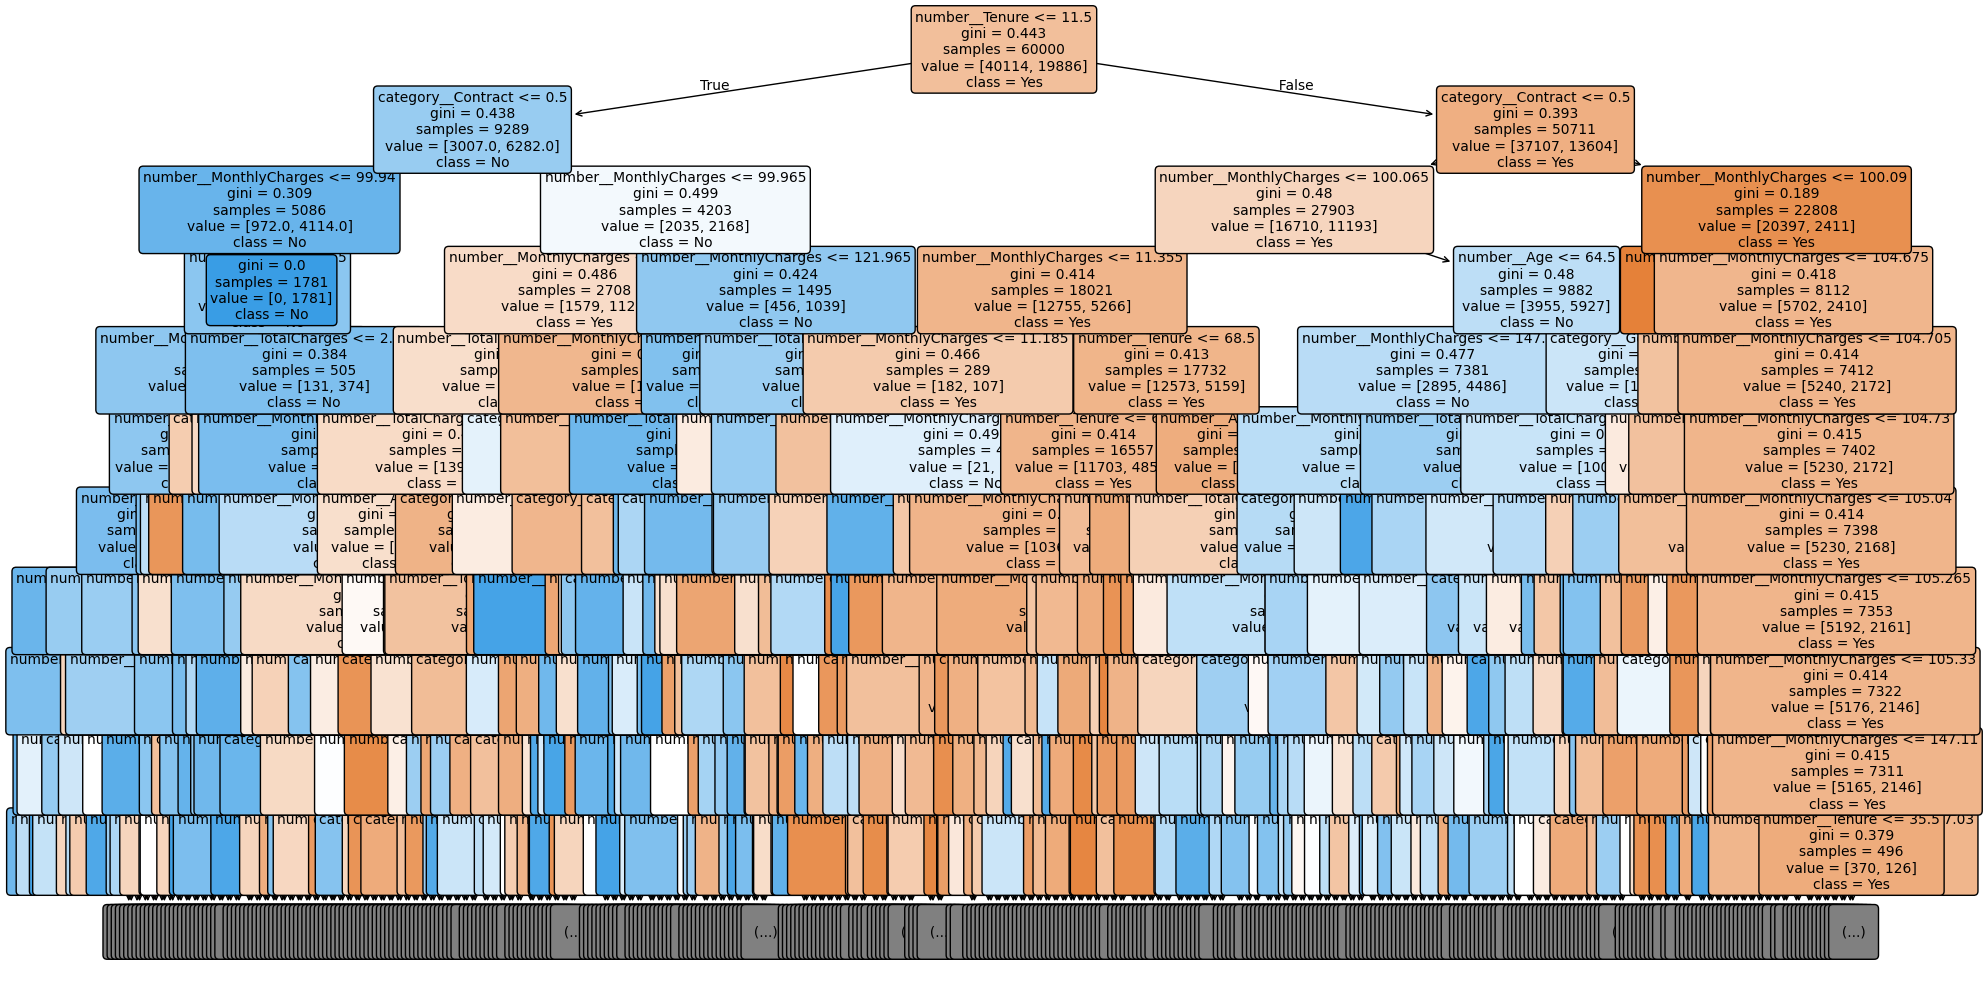

In [52]:
# Graphviz 설치가 어려운 경우, sklearn의 plot_tree 함수를 사용하여 트리를 시각화할 수 있습니다.

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
tree_model = pipeline.named_steps["model"]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Yes', 'No'],
    filled=True,
    rounded=True,
    max_depth=10,
    fontsize=10
)
plt.tight_layout()
plt.show()

In [53]:
# fit() 뒤에 feature 중요도 조회
fi = pipeline.named_steps["model"].feature_importances_
fi

array([0.02713529, 0.10310437, 0.04933055, 0.180498  , 0.30917715,
       0.20116508, 0.12958956])

In [54]:
fi.sum()

np.float64(1.0)

In [55]:
import pandas as pd
fi_s = pd.Series(fi, index=feature_names).sort_values(ascending=False)
fi_s

number__MonthlyCharges     0.309177
number__TotalCharges       0.201165
number__Tenure             0.180498
number__Age                0.129590
category__Contract         0.103104
category__PaymentMethod    0.049331
category__Gender           0.027135
dtype: float64

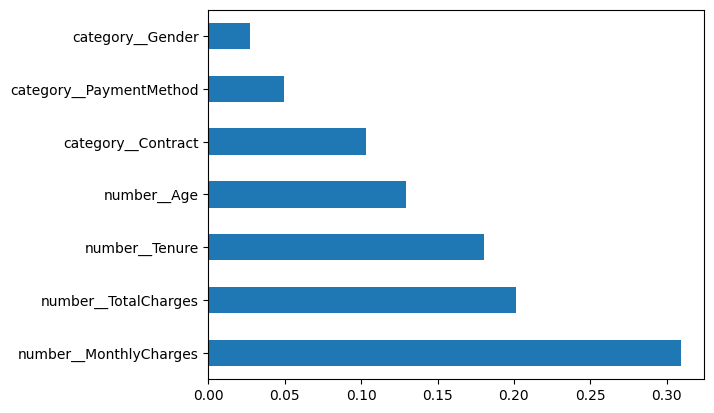

In [56]:
fi_s.plot(kind='barh');

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

categorical_columns = ['Gender','Contract','PaymentMethod'] 
numeric_columns = ['Tenure','MonthlyCharges', 'TotalCharges','Age'] 

# 범주형 컬럼 전처리 파이프라인
categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("label", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# 수치형 컬럼 전처리 파이프라인
numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    # ("scaler", StandardScaler())
])

# ColumnTransformer로 컬럼별로 전처리 파이프라인 정의.
preprocessing = ColumnTransformer([
    ("category", categorical_preprocessing, categorical_columns),
    ("number", numeric_preprocessing, numeric_columns)
])
# preprocessing
# 전처리기와 모델을 묶는 파이프라인

pipeline = Pipeline([
    ("preprocessor", preprocessing),  # 1
    ("model", DecisionTreeClassifier(random_state=0))  # 2
])


# gridsearch
## model : C - [0.1, 0.5, 1, 10]
## 수치형 전처리 - imputer : ["mean", "median"]
param = {
    "model__max_depth": [30, 50, 70, 100],
    "model__min_samples_split": [2, 5, 10],
    "preprocessor__number__imputer__strategy": ["mean", "median"]
    # Pipeline의 processor 안의 number 안의 imputer의 하이퍼파라미터 strategy
}
gs = GridSearchCV(
    pipeline,
    param,
    scoring="accuracy", cv=4, n_jobs=-1
)
gs.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [30, 50, ...], 'model__min_samples_split': [2, 5, ...], 'preprocessor__number__imputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [58]:
gs.best_params_

{'model__max_depth': 30,
 'model__min_samples_split': 10,
 'preprocessor__number__imputer__strategy': 'mean'}

In [59]:
r = pd.DataFrame(gs.cv_results_)
r.sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__min_samples_split,param_preprocessor__number__imputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
5,0.839392,0.112330,0.055748,0.028436,30,10,median,"{'model__max_depth': 30, 'model__min_samples_s...",0.694467,0.700133,0.704733,0.709067,0.702100,0.005422,1
4,0.713494,0.039705,0.048633,0.014614,30,10,mean,"{'model__max_depth': 30, 'model__min_samples_s...",0.694467,0.700133,0.704733,0.709067,0.702100,0.005422,1
3,0.741788,0.060222,0.040094,0.003464,30,5,median,"{'model__max_depth': 30, 'model__min_samples_s...",0.693467,0.703067,0.702800,0.708733,0.702017,0.005476,3
2,0.912367,0.142268,0.042016,0.008460,30,5,mean,"{'model__max_depth': 30, 'model__min_samples_s...",0.693467,0.703067,0.702800,0.708733,0.702017,0.005476,3
0,0.733824,0.055081,0.110529,0.023450,30,2,mean,"{'model__max_depth': 30, 'model__min_samples_s...",0.691267,0.698400,0.700200,0.705200,0.698767,0.004996,5


In [60]:
best_model = gs.best_estimator_

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
fi = pd.Series(
    best_model.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
fi

number__MonthlyCharges     0.329140
number__Tenure             0.207243
number__TotalCharges       0.159351
category__Contract         0.155969
number__Age                0.100485
category__PaymentMethod    0.032163
category__Gender           0.015650
dtype: float64

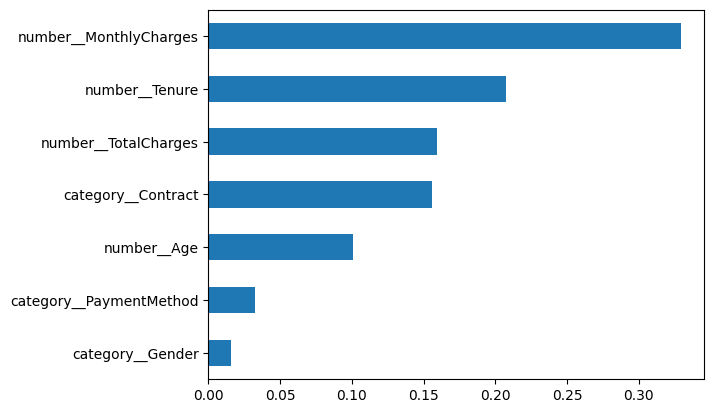

In [61]:
fi.sort_values().plot(kind="barh");

In [62]:
from sklearn.tree import export_graphviz
from graphviz import Source

graph = Source(
    export_graphviz(
        best_model, 
        feature_names=feature_names,
        class_names = ["Yes", "No"],
        filled=True,
        rounded=True
    )
)
graph

AttributeError: 'Pipeline' object has no attribute 'tree_'

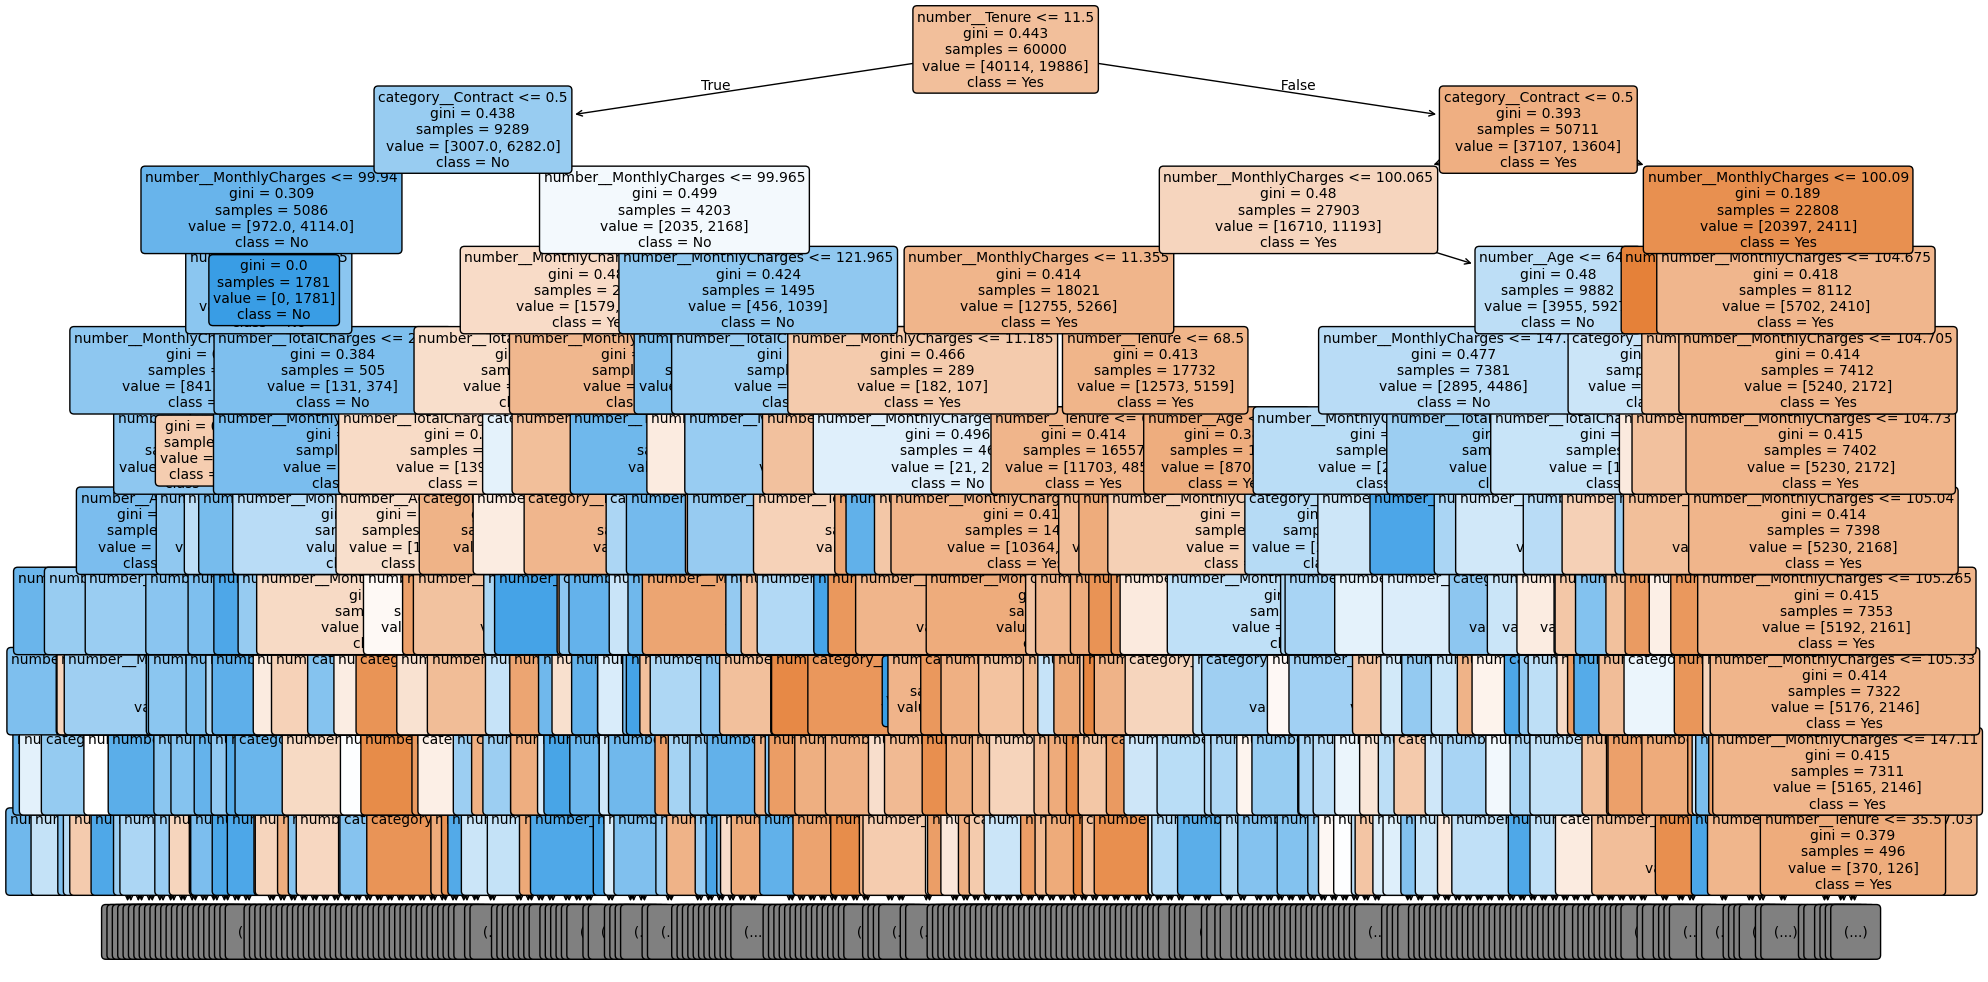

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    best_model.named_steps["model"],
    feature_names=feature_names,
    class_names=["Yes", "No"],
    filled=True,
    rounded=True,
    max_depth=10,
    fontsize=10
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

categorical_columns = ['Gender', 'Contract', 'PaymentMethod']
numeric_columns = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'Age']


# ── 1. 범주형 전처리 ──────────────────────────────
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_columns] = cat_imputer.fit_transform(X_train[categorical_columns])
X_val[categorical_columns]   = cat_imputer.transform(X_val[categorical_columns])   # ← 추가
X_test[categorical_columns]  = cat_imputer.transform(X_test[categorical_columns])

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train[categorical_columns] = encoder.fit_transform(X_train[categorical_columns])
X_val[categorical_columns]   = encoder.transform(X_val[categorical_columns])       # ← 추가
X_test[categorical_columns]  = encoder.transform(X_test[categorical_columns])

# ── 2. 수치형 전처리 ──────────────────────────────
num_imputer = SimpleImputer(strategy="median")
X_train[numeric_columns] = num_imputer.fit_transform(X_train[numeric_columns])
X_val[numeric_columns]   = num_imputer.transform(X_val[numeric_columns])           # ← 추가
X_test[numeric_columns]  = num_imputer.transform(X_test[numeric_columns])


In [64]:
# "model__" 접두사 제거
best_params = {k.replace("model__", ""): v for k, v in gs.best_params_.items() if k.startswith("model__")}
print("정제된 파라미터:", best_params)

# 모델 생성 및 학습
best_model = RandomForestClassifier(
    **best_params,
    random_state=0,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

# 추론
pred_test       = best_model.predict(X_test)
pred_test_proba = best_model.predict_proba(X_test)

정제된 파라미터: {'max_depth': 30, 'min_samples_split': 10}


In [65]:
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_test, pred_test, pred_test_proba[:, 1], "Test set"
)

Test set
정확도: 0.74915
재현율: 0.5211947503394178
정밀도: 0.6521328803322008
F1 점수: 0.5793577597048714
Average Precision: 0.6639976330489227
ROC-AUC Score: 0.8000541290284724
